In [1]:
pip install keras


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Activation
# other imports as needed


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Activation
# from keras.callbacks import TensorBoard, ModelCheckpoint, ReduceLROnPlateau
import datetime

In [12]:
import os
print(os.getcwd())

C:\Users\eugen


In [11]:
os.chdir('C:/Users/eugen/')

In [13]:
data = pd.read_csv('dataset/NVDA.csv')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-02-19,39.227501,39.972500,39.035000,39.160000,38.855831,55189200
1,2019-02-20,39.455002,40.314999,39.342499,39.637501,39.329617,54098800
2,2019-02-21,39.764999,40.012501,38.794998,38.942501,38.640015,44854800
3,2019-02-22,39.465000,39.987499,39.327499,39.797501,39.488373,40174000
4,2019-02-25,40.639999,41.320000,39.584999,39.672501,39.364338,65602000


In [14]:
high_prices = data['High'].values
low_prices = data['Low'].values
mid_prices = (high_prices + low_prices) / 2

In [15]:

seq_len = 50
sequence_length = seq_len + 1

result = []
for index in range(len(mid_prices) - sequence_length):
    result.append(mid_prices[index: index + sequence_length])

In [16]:
normalized_data = []
for window in result:
    normalized_window = [((float(p) / float(window[0])) - 1) for p in window]
    normalized_data.append(normalized_window)

result = np.array(normalized_data)

# split train and test data
row = int(round(result.shape[0] * 0.9))
train = result[:row, :]
np.random.shuffle(train)

x_train = train[:, :-1]
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
y_train = train[:, -1]

x_test = result[row:, :-1]
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
y_test = result[row:, -1]

x_train.shape, x_test.shape

((1087, 50, 1), (121, 50, 1))

In [17]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(50, 1)))

model.add(LSTM(64, return_sequences=False))

model.add(Dense(1, activation='linear'))

model.compile(loss='mse', optimizer='rmsprop')

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 50, 50)            10400     
                                                                 
 lstm_1 (LSTM)               (None, 64)                29440     
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 39905 (155.88 KB)
Trainable params: 39905 (155.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [18]:
model.fit(x_train, y_train,
    validation_data=(x_test, y_test),
    batch_size=10,
    epochs=20)

Epoch 1/20

109/109 [==============================] - 5s 24ms/step - loss: 0.0079 - val_loss: 0.0044
Epoch 2/20
109/109 [==============================] - 2s 17ms/step - loss: 0.0038 - val_loss: 0.0023
Epoch 3/20
109/109 [==============================] - 2s 15ms/step - loss: 0.0032 - val_loss: 0.0019
Epoch 4/20
109/109 [==============================] - 2s 15ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 5/20
109/109 [==============================] - 2s 16ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 6/20
109/109 [==============================] - 2s 15ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 7/20
109/109 [==============================] - 2s 17ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 8/20
109/109 [==============================] - 2s 17ms/step - loss: 0.0021 - val_loss: 9.5728e-04
Epoch 9/20
109/109 [==============================] - 2s 17ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 10/20
109/109 [==============================] - 2s 17ms/step - loss: 0.0019 - v

4/4 [==============================] - 1s 8ms/step


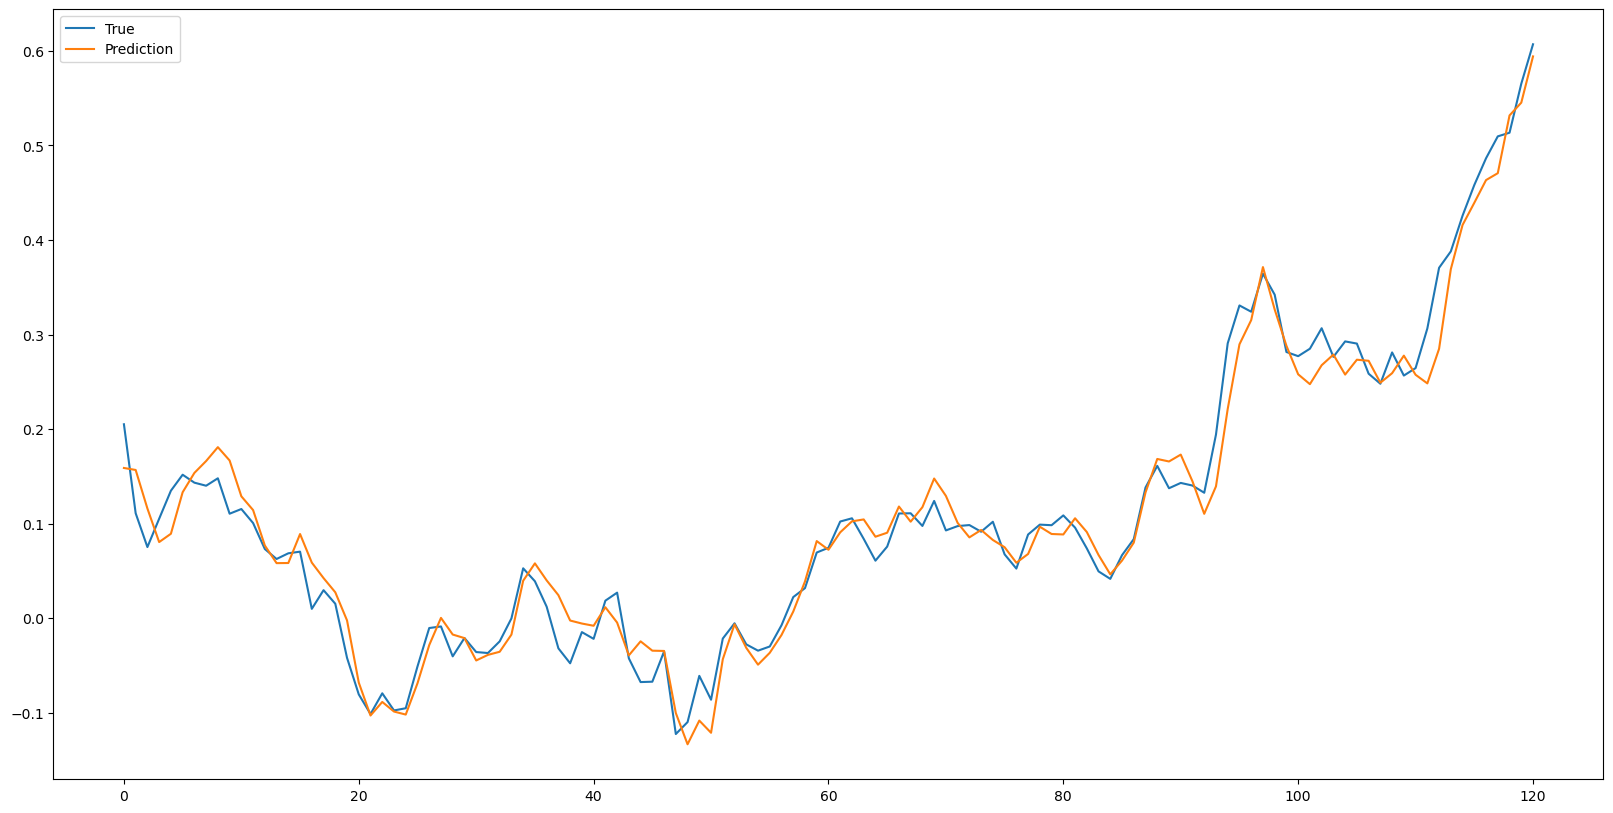

In [19]:
pred = model.predict(x_test)

fig = plt.figure(facecolor='white', figsize=(20, 10))
ax = fig.add_subplot(111)
ax.plot(y_test, label='True')
ax.plot(pred, label='Prediction')
ax.legend()
plt.show()